<a href="https://colab.research.google.com/github/hughman1986/StockResearch/blob/main/CANSLIM%E9%81%B8%E8%82%A1%E5%99%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### C – Current Earnings（當季盈餘）

最新一季的每股盈餘（EPS）成長率應該達到 +25% 以上。

顯示公司近期業務強勁，基本面有爆發力。

### A – Annual Earnings（年度盈餘）

過去 3 年以上的年 EPS 成長率應該穩定且高速（通常 >25%）。

長期趨勢要往上，而不是偶爾一季大漲。

### N – New（新產品 / 新高 / 新故事）

公司推出了 新產品、新技術、新商業模式，或進入新市場。

股價創下 新高也屬於這一類，因為市場資金流入表示強勢。

### S – Supply and Demand（供需關係）

董監事、大股東、機構買進的股票越多越好。

市值較小、股數有限的公司，股價更容易因需求增加而上漲。

### L – Leader or Laggard（領導股 vs. 落後股）

投資要選產業中的 領導股（Leader），而不是落後股（Laggard）。

可用 相對強弱指標（RS Rating） 判斷：RS 排名在 80 以上的通常比較好。

### I – Institutional Sponsorship（機構進駐）

要有 基金、機構投資人持有，代表專業資金認同。

但也不能太多（避免已經過度擁擠）。

### M – Market Direction（大盤方向）

必須順勢而為：大盤處於上升趨勢才適合進場。

O’Neil 強調「3/4 的股票跟著大盤走」，逆勢操作勝率低。

## 補充與注意

- 資料缺漏：部分公司（特別是非美股、金融業、或新掛牌）在 yfinance 可能缺 EPS/平均股數等欄位；上面程式已盡量 fallback（以淨利/平均股數估 EPS），仍可能 NaN，建議手動複核。

- I（機構）：heldPercentInstitutions 在某些標的或版本可能取不到；可視為「未知」，不當硬性條件。

- N（新）：用 52 週新高/近新高 + 放量代理「新產品/新故事/新高」的概念，實務上可加入新聞/財報敘述判讀。

- M（大盤）：此處用 S&P500 的 50MA>200MA 且收盤>200MA 判斷「順勢」，你也可改用 跟蹤日（Follow-Through Day） 的更嚴謹判法。

- S（供需）：O’Neil 偏好股本較小且突破放量；此處用「流通或發行股數 + 放量 + 流動性」代理。

- 效能：財報是逐檔抓，清單很大時請調大 per_ticker_pause_sec 或拆批處理。

## 0) 安裝與匯入

In [2]:

import time
import math
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
pd.options.mode.copy_on_write = True


## 1) 參數設定（可調整門檻）

In [3]:
PARAMS = {
    # C: 當季 EPS YoY 成長門檻
    "quarterly_eps_yoy_min": 0.25,     # >= +25%

    # A: 年度 EPS 近 3 年複合成長率門檻
    "annual_eps_cagr_min": 0.25,       # >= +25%

    # N: 新（以技術面代理）— 52 週新高附近突破視為「新」
    "lookback_high_days": 252,         # 約等同 52 週
    "new_high_tolerance": 0.01,        # 現價距離 52 週高點 1% 內視為接近突破
    "breakout_window_days": 10,        # 最近 N 天內若創新高視為有 N 訊號

    # S: 供需（以股本與量能代理）
    "max_shares_outstanding": 1_000_000_000, # 流通股 <= 10 億較佳（可調）
    "min_avg_dollar_vol": 20_000_000,       # 50 日平均成交金額最低門檻（流動性）
    "volume_surge_ratio": 1.5,              # 突破日放量倍率

    # L: 產業領先（以相對強弱代理）
    "rs_lookback_days": 126,          # 6 個月報酬作為 RS 依據
    "rs_percentile_min": 0.80,        # 80 分位以上

    # I: 機構進駐（可由 info 的 heldPercentInstitutions 代理）
    "institution_min": 0.10,          # 機構持股比例至少 10%（若可取得）

    # M: 大盤方向（以 S&P500 50MA>200MA 且收盤>200MA）
    "index": "^GSPC",
    "sma_short": 50,
    "sma_long": 200,

    # 下載區間/解析度
    "price_period": "3y",
    "price_interval": "1d",

    # 安全設定
    "per_ticker_pause_sec": 0.4,      # 避免打太猛被限流
}


## 2) 工具函式

In [4]:
def _safe(row, key, default=None):
    try:
        return row.get(key, default)
    except Exception:
        return default

def get_prices(tickers, period="3y", interval="1d"):
    """
    一次抓多檔價格與量能，回傳 MultiIndex DataFrame:
    columns 為 (欄位, 股票代號) 或 (股票代號, 欄位)，視 yfinance 版本而定。
    我們會統一整理成 columns 層級: ['Ticker','Field'] 方便後續處理。
    """
    df = yf.download(
        tickers=tickers,
        period=period,
        interval=interval,
        auto_adjust=False,
        group_by="ticker",
        threads=True
    )

    # 統一欄位層級: ['Ticker','Field']
    if isinstance(df.columns, pd.MultiIndex):
        if df.columns.names[0] in ("Symbols", "Ticker"):
            df = df.copy()
            df.columns.set_names(["Ticker","Field"], inplace=True)
        else:
            # 某些版本可能相反 ('Field','Ticker')
            df = df.copy()
            df.columns.set_names(["Field","Ticker"], inplace=True)
            df = df.swaplevel(axis=1).sort_index(axis=1)
    else:
        # 單一股票時，補齊層級
        df = pd.concat({tickers[0] if isinstance(tickers, list) else tickers: df}, axis=1)
        df.columns.set_names(["Ticker","Field"], inplace=True)

    return df

def get_income_statements(ticker: str):
    """
    取得年/季損益表（DataFrame），index 為科目，columns 為期間(日期)。
    回傳 (annual_df, quarterly_df)，若抓不到則回傳 (None, None)。
    """
    try:
        tk = yf.Ticker(ticker)
        a = tk.income_stmt  # 年度
        q = tk.quarterly_income_stmt  # 季度
        return a, q
    except Exception:
        return None, None

def compute_eps_series_from_is(is_df: pd.DataFrame):
    """
    從損益表 DataFrame 推導 EPS series。
    優先使用 'Diluted EPS' 或 'Basic EPS'。
    若沒有，嘗試用 Net Income / Average Shares 推估。
    回傳 pd.Series（index=period columns）或 None。
    """
    if is_df is None or is_df.empty:
        return None

    idx = is_df.index.str.lower()

    # 優先找 EPS 欄位
    for label in ["diluted eps", "basic eps", "eps (diluted)", "eps (basic)"]:
        if label in idx:
            s = is_df.iloc[idx.get_loc(label)].copy()
            s.name = "EPS"
            return s

    # 嘗試用 Net Income / Average Shares
    net_keys = ["net income", "net income common stockholders", "net income applicable to common shares"]
    basic_shares_keys = ["basic average shares", "basic weighted average shares", "weighted average shares"]
    diluted_shares_keys = ["diluted average shares", "diluted weighted average shares"]

    net = None
    for k in net_keys:
        if k in idx:
            net = is_df.iloc[idx.get_loc(k)].copy()
            break
    shares = None
    for k in diluted_shares_keys + basic_shares_keys:
        if k in idx:
            shares = is_df.iloc[idx.get_loc(k)].copy()
            break

    if net is not None and shares is not None:
        with np.errstate(divide='ignore', invalid='ignore'):
            eps = net / shares
            eps.name = "EPS"
            return eps

    return None

def yoy_growth(curr, prev):
    if prev is None or prev == 0 or pd.isna(prev):
        return np.nan
    return (curr - prev) / abs(prev)

def cagr(start, end, years):
    if start is None or start <= 0 or pd.isna(start) or pd.isna(end) or years <= 0:
        return np.nan
    try:
        return (end / start) ** (1 / years) - 1
    except Exception:
        return np.nan

def rolling_sma(series, n):
    return series.rolling(n, min_periods=n).mean()

def rs_percentile(series_returns: pd.Series):
    """
    對於 universe 的報酬率序列，轉為 0~1 百分等級（越大越領先）。
    """
    s = series_returns.rank(pct=True, method="average")
    return s

def get_float_or_outstanding_shares(ticker: str):
    """
    嘗試從 yfinance 取得流通或發行股數（當做供給代理）。
    回傳 int 或 None。
    """
    try:
        tk = yf.Ticker(ticker)
        info = tk.get_info()
        # 可能的欄位：impliedSharesOutstanding, sharesOutstanding, floatShares
        for key in ["floatShares", "impliedSharesOutstanding", "sharesOutstanding"]:
            v = info.get(key)
            if v and not pd.isna(v):
                return int(v)
    except Exception:
        pass

    try:
        # 新 API：fast_info 有 shares（不一定是 float）
        tk = yf.Ticker(ticker)
        fi = tk.fast_info
        v = fi.get("shares", None)
        if v:
            return int(v)
    except Exception:
        pass
    return None

def get_institution_percent(ticker: str):
    """
    嘗試取得機構持股比例（0~1）。若取不到則回傳 None。
    """
    try:
        tk = yf.Ticker(ticker)
        info = tk.get_info()
        for key in ["heldPercentInstitutions", "institutionPercent", "institutionsPercent"]:
            v = info.get(key)
            if v is not None and not pd.isna(v):
                # 某些欄位已是 0~1；若是 >1 代表百分比 0~100
                return float(v) if v <= 1 else float(v) / 100.0
    except Exception:
        pass
    return None


## 3) 下載大盤與個股價量

In [6]:
# 先設定股票清單：可以先用小清單測試，再替換成你要的清單
# tickers = ["AAPL", "MSFT", "NVDA", "AMD", "META", "TSLA", "CELH", "ON", "MELI", "LULU"]


# 設定篩選條件（單位：美元）
MIN_CAP = 5e8      # 5億
MAX_CAP = 2e10     # 200億

# 從 market_caps.csv 讀取股票代號列表
try:
    mid_large_df = pd.read_csv("./drive/MyDrive/StopCheckingThePriceData/market_caps.csv")

    print(f"從 market_caps.csv 載入 {len(mid_large_df)} 檔股票。")

    # 確保 MarketCap 欄位為數值
    mid_large_df["MarketCap"] = pd.to_numeric(mid_large_df["MarketCap"], errors="coerce")
    mid_large_df.dropna(subset=["MarketCap"], inplace=True)

    # 依條件篩選市值區間
    filtered_df = mid_large_df[
        (mid_large_df["MarketCap"] >= MIN_CAP) &
        (mid_large_df["MarketCap"] <= MAX_CAP)
    ].copy()
    filtered_df["MarketCap_Billion"] = (filtered_df["MarketCap"] / 1e9).round(1)
    filtered_df = filtered_df.sort_values("MarketCap", ascending=False).reset_index(drop=True)
    # 產出股票清單
    tickers = filtered_df["Ticker"].dropna().tolist()
    print(f"篩出 {len(tickers)} 檔股票（市值介於 {MIN_CAP/1e9:.0f}B～{MAX_CAP/1e9:.0f}B 美元）")
    display(filtered_df.head(10))

except FileNotFoundError:
    print("錯誤：找不到 market_caps.csv 檔案，請先執行股票池產生器。")
    tickers = [] # 若檔案不存在，設為空列表避免後續錯誤
print(tickers)


# 下載個股價量
prices = get_prices(
    tickers=tickers,
    period=PARAMS["price_period"],
    interval=PARAMS["price_interval"]
)

# 下載大盤（M 條件）
index_prices = yf.download(
    tickers=PARAMS["index"],
    period=PARAMS["price_period"],
    interval=PARAMS["price_interval"],
    auto_adjust=False
)


從 market_caps.csv 載入 2462 檔股票。
篩出 1435 檔股票（市值介於 0B～20B 美元）


,Ticker,MarketCap,MarketCap_Billion
0,TPL,1.994054e+10,19.9
1,TRMB,1.993466e+10,19.9
2,NI,1.990775e+10,19.9
3,DGX,1.981917e+10,19.8
4,FSLR,1.980334e+10,19.8
5,ZBH,1.966301e+10,19.7
6,GPN,1.965117e+10,19.7
7,ON,1.949170e+10,19.5
8,L,1.945034e+10,19.5
9,BIIB,1.939652e+10,19.4


['TPL', 'TRMB', 'NI', 'DGX', 'FSLR', 'ZBH', 'GPN', 'ON', 'L', 'BIIB', 'KEY', 'GEN', 'MKC', 'INVH', 'GDDY', 'GPC', 'FFIV', 'ERIE', 'WY', 'CTRA', 'STLD', 'HAL', 'J', 'PKG', 'ESS', 'RL', 'IT', 'WST', 'TER', 'PFG', 'WAT', 'NWSA', 'NWS', 'LNT', 'MAA', 'PNR', 'SNA', 'EVRG', 'BG', 'IFF', 'ZBRA', 'FTV', 'EXPD', 'LYB', 'HRL', 'LUV', 'CLX', 'INCY', 'BALL', 'HOLX', 'DECK', 'DOW', 'DPZ', 'BLDR', 'BBY', 'APTV', 'MAS', 'BF-B', 'FDS', 'UDR', 'JOBY', 'OMC', 'KIM', 'ALLE', 'COO', 'EG', 'CHRW', 'TXT', 'JBHT', 'TKO', 'AVY', 'REG', 'CF', 'BEN', 'PAYC', 'CNC', 'SOLV', 'ARE', 'IONQ', 'FN', 'AVAV', 'BAX', 'NDSN', 'IEX', 'SJM', 'DOC', 'JKHY', 'HIMS', 'GNRC', 'POOL', 'GL', 'VTRS', 'CPT', 'BXP', 'UHS', 'OKLO', 'WYNN', 'PNW', 'HAS', 'NCLH', 'KTOS', 'SWK', 'HST', 'SWKS', 'HII', 'WBA', 'AIZ', 'MRNA', 'MOS', 'ALGN', 'AKAM', 'RVTY', 'TAP', 'AOS', 'CPB', 'SPXC', 'AES', 'MGM', 'ENSG', 'DVA', 'IVZ', 'CAG', 'STRL', 'IPG', 'GTLS', 'BBIO', 'ALB', 'EPAM', 'WTS', 'MTCH', 'BE', 'NXT', 'MOH', 'UMBF', 'KMX', 'ONB', 'DAY', 'CVL

[*********************100%***********************]  1435 of 1435 completed
[*********************100%***********************]  1 of 1 completed


## 4) 計算大盤 M（Market Direction）

In [7]:
def market_trend_ok(index_df, sma_short=50, sma_long=200):
    close = index_df["Close"].dropna().copy()
    ma_s = rolling_sma(close, sma_short)
    ma_l = rolling_sma(close, sma_long)
    if len(ma_l.dropna()) == 0:
        return False, {"index_close": np.nan, "sma_short": np.nan, "sma_long": np.nan}

    latest_close = close.iloc[-1].item()
    latest_ma_s = ma_s.iloc[-1].item()
    latest_ma_l = ma_l.iloc[-1].item()
    ok = (latest_ma_s > latest_ma_l) and (latest_close > latest_ma_l)
    return ok, {
        "index_close": float(latest_close),
        "sma_short": float(latest_ma_s),
        "sma_long": float(latest_ma_l),
        }

M_pass, M_metrics = market_trend_ok(
    index_prices,
    PARAMS["sma_short"],
    PARAMS["sma_long"]
)
M_pass, M_metrics

(True,
 {'index_close': 6664.009765625,
  'sma_short': 6564.03677734375,
  'sma_long': 6066.177241210938})

## 5) 計算 RS（Leader/Laggard）、新高、量能等技術面

In [8]:
# 準備個股日線收盤與成交量表
close_wide = prices.xs("Close", axis=1, level="Field")
vol_wide   = prices.xs("Volume", axis=1, level="Field")

# RS：以 6 個月（約 126 交易日）報酬率衡量
def trailing_return(s: pd.Series, lookback=126):
    s = s.dropna()
    if len(s) <= lookback:
        return np.nan
    try:
        return s.iloc[-1] / s.iloc[-lookback] - 1.0
    except Exception:
        return np.nan

ret6m = close_wide.apply(trailing_return, lookback=PARAMS["rs_lookback_days"])
rs_pct = rs_percentile(ret6m)

# 52 週新高與突破判定
rolling_high = close_wide.rolling(PARAMS["lookback_high_days"], min_periods=20).max()
latest_close = close_wide.tail(1).T.iloc[:,0]
latest_high  = rolling_high.tail(1).T.iloc[:,0]

near_new_high = (latest_close >= latest_high * (1 - PARAMS["new_high_tolerance"]))

# 最近 N 天內是否創新高
recent_window = close_wide.tail(PARAMS["breakout_window_days"])
recent_high = recent_window.max()
recent_made_new_high = (recent_high >= rolling_high.tail(PARAMS["breakout_window_days"]).max().iloc[-1])

# 放量判定：以 50 日均量當基準
avg_vol_50 = vol_wide.rolling(50, min_periods=20).mean().tail(1).T.iloc[:,0]
last_vol   = vol_wide.tail(1).T.iloc[:,0]
volume_surge = (last_vol >= PARAMS["volume_surge_ratio"] * avg_vol_50).reindex(close_wide.columns).fillna(False)

# 50 日平均「成交金額」判定（流動性）
avg_dollar_vol = (close_wide.rolling(50, min_periods=20).mean() * vol_wide.rolling(50, min_periods=20).mean()).tail(1).T.iloc[:,0]
enough_liquidity = (avg_dollar_vol >= PARAMS["min_avg_dollar_vol"])


## 6) 取得年/季 EPS 並計算 C & A

In [9]:
from tqdm.notebook import tqdm


records = []

for tk in tqdm(close_wide.columns, desc="計算 CANSLIM 指標（財報與條件彙整）", unit="檔"):
    a_is, q_is = get_income_statements(tk)
    # 年度 EPS
    eps_a = compute_eps_series_from_is(a_is)
    # 季度 EPS
    eps_q = compute_eps_series_from_is(q_is)

    # C: 季 EPS 同期 YoY
    c_pass = np.nan
    c_yoy  = np.nan
    if eps_q is not None and len(eps_q.dropna()) >= 5:
        eps_q = eps_q.sort_index()  # 由舊到新
        curr = eps_q.iloc[-1]
        # 同期 YoY：往前找大約 4 季前（注意公司可能非標準季，使用對齊最接近期）
        prev = eps_q.iloc[-5] if len(eps_q) >= 5 else np.nan
        c_yoy = yoy_growth(curr, prev)
        c_pass = (c_yoy >= PARAMS["quarterly_eps_yoy_min"])

    # A: 年 EPS 3 年 CAGR
    a_pass = np.nan
    a_cagr = np.nan
    if eps_a is not None and len(eps_a.dropna()) >= 4:
        eps_a = eps_a.sort_index()
        start = eps_a.iloc[-4] # t-3 年
        end   = eps_a.iloc[-1] # 近一年
        a_cagr = cagr(start, end, years=3)
        a_pass = (a_cagr >= PARAMS["annual_eps_cagr_min"])

    # N: 新（靠技術指標代理）
    n_pass = bool(near_new_high.get(tk, False) or recent_made_new_high.get(tk, False))

    # S: 供需（股本 + 放量 + 流動性）
    shares = get_float_or_outstanding_shares(tk)
    s_shares_ok = (shares is not None and shares <= PARAMS["max_shares_outstanding"])
    s_liquidity_ok = bool(enough_liquidity.get(tk, False))
    s_volume_surge = bool(volume_surge.get(tk, False))
    s_pass = bool(s_shares_ok and s_liquidity_ok and s_volume_surge)

    # L: 領先 — RS 百分位
    rs_val = float(rs_pct.get(tk, np.nan))
    l_pass = (rs_val >= PARAMS["rs_percentile_min"])

    # I: 機構持股比例
    inst = get_institution_percent(tk)
    i_pass = (inst is not None and inst >= PARAMS["institution_min"])

    # 價格/均量數據
    last_c = float(latest_close.get(tk, np.nan))
    last_h = float(latest_high.get(tk, np.nan))
    adv50  = float(avg_vol_50.get(tk, np.nan))
    dolvol50 = float(avg_dollar_vol.get(tk, np.nan))

    records.append({
        "Ticker": tk,
        "C_pass": bool(c_pass) if not pd.isna(c_pass) else False,
        "C_qEPS_YoY": float(c_yoy) if not pd.isna(c_yoy) else np.nan,
        "A_pass": bool(a_pass) if not pd.isna(a_pass) else False,
        "A_EPS_CAGR3y": float(a_cagr) if not pd.isna(a_cagr) else np.nan,
        "N_pass": n_pass,
        "S_pass": s_pass,
        "S_shares_ok": s_shares_ok,
        "S_liquidity_ok": s_liquidity_ok,
        "S_volume_surge": s_volume_surge,
        "L_pass": l_pass,
        "L_RS_pct": rs_val,
        "I_pass": i_pass,
        "I_inst_percent": float(inst) if inst is not None else np.nan,
        "M_pass": M_pass,
        "Price": last_c,
        "52w_High": last_h,
        "AvgVol50": adv50,
        "AvgDollarVol50": dolvol50,
        "Shares": shares if shares is not None else np.nan,
    })

    time.sleep(PARAMS["per_ticker_pause_sec"])  # 友善一點，避免 API 節流

result = pd.DataFrame.from_records(records)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
result.to_csv(f"./drive/MyDrive/StopCheckingThePriceData/CANSLIM_SCANNER_Result_{timestamp}.csv", index=False)

result.head(20)


計算 CANSLIM 指標（財報與條件彙整）:   0%|          | 0/1435 [00:00<?, ?檔/s]

/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:104: RuntimeWarning: invalid value encountered in scalar power
  return (end / start) ** (1 / years) - 1
/tmp/ipython-input-1431451464.py:1

,Ticker,C_pass,C_qEPS_YoY,A_pass,A_EPS_CAGR3y,N_pass,S_pass,S_shares_ok,S_liquidity_ok,S_volume_surge,L_pass,L_RS_pct,I_pass,I_inst_percent,M_pass,Price,52w_High,AvgVol50,AvgDollarVol50,Shares
0,HUT,True,2.475000,False,NaN,True,False,True,True,False,True,0.986053,True,0.675390,True,48.459999,53.910000,6596380.0,2.167188e+08,85487119
1,MCB,False,0.173333,False,-0.027630,True,False,True,False,False,False,0.612273,True,0.922140,True,72.000000,80.699997,84460.0,6.437997e+06,9203437
2,IBTA,True,1.060606,False,NaN,True,False,True,False,False,False,0.029986,True,0.526060,True,31.959999,76.889999,580076.0,1.627856e+07,12832275
3,AUB,False,-0.520000,False,-0.117577,True,False,True,True,False,False,0.674338,True,0.851330,True,33.910000,43.549999,1002386.0,3.507589e+07,141177138
4,LTH,False,0.230769,False,NaN,True,True,True,True,True,False,0.110181,True,0.803700,True,25.700001,33.230000,2090294.0,5.774354e+07,161164744
5,ALRS,True,1.516129,False,-0.308981,True,False,True,False,False,False,0.566946,True,0.569130,True,20.990000,24.360001,83754.0,1.851834e+06,23324984
6,BG,True,4.437500,False,-0.163285,True,False,True,True,False,False,0.550209,True,0.746300,True,97.500000,97.500000,2030552.0,1.686065e+08,165839409
7,PAYO,False,-0.444444,False,NaN,False,False,True,False,False,False,0.175732,True,0.968110,True,5.800000,11.050000,2925784.0,1.896142e+07,276262590
8,GEF,False,-0.266667,False,-0.115862,True,False,True,False,False,False,0.470711,True,0.904640,True,59.020000,72.150002,202526.0,1.261603e+07,27960080
9,MVST,False,-0.320000,False,NaN,False,False,True,True,False,True,0.949093,True,0.236630,True,5.830000,6.400000,8864366.0,3.156069e+07,194196730


In [17]:

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
result.to_csv(f"./drive/MyDrive/StopCheckingThePriceData/CANSLIM_SCANNER_Result_{timestamp}.csv", index=False)


## 7) 綜合篩選與排序（產出候選名單）

In [10]:
# 你可以決定「必過」的欄位（經典作法至少：C、A、L、M）
must_pass_cols = ["C_pass", "A_pass", "L_pass", "M_pass"]

screen = result.copy()
for col in must_pass_cols:
    screen = screen[screen[col] == True]

# 再按 RS 與 EPS 成長排序
screen = screen.sort_values(
    by=["L_RS_pct", "C_qEPS_YoY", "A_EPS_CAGR3y"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(f"候選數量：{len(screen)} / {len(result)}")
screen.head(20)


候選數量：17 / 1435


,Ticker,C_pass,C_qEPS_YoY,A_pass,A_EPS_CAGR3y,N_pass,S_pass,S_shares_ok,S_liquidity_ok,S_volume_surge,L_pass,L_RS_pct,I_pass,I_inst_percent,M_pass,Price,52w_High,AvgVol50,AvgDollarVol50,Shares
0,CECO,True,1.166667,True,1.080084,True,False,True,True,False,True,0.944212,True,0.903790,True,48.880001,53.099998,523594.0,2.531022e+07,29997809
1,STRL,True,0.383234,True,0.566832,True,False,True,True,False,True,0.942817,False,0.010271,True,355.579987,371.839996,493668.0,1.572362e+08,29586632
2,HL,True,1.250000,True,3.542801,True,False,True,True,False,True,0.916318,True,0.673200,True,13.930000,15.240000,26023356.0,2.706325e+08,630983881
3,IESC,True,0.426966,True,0.464295,True,True,True,True,True,True,0.914923,True,0.981150,True,386.200012,400.000000,142970.0,5.253313e+07,8808234
4,GCT,True,0.400000,True,0.641375,True,False,True,True,False,True,0.907252,True,0.600680,True,26.650000,32.480000,1142580.0,3.293430e+07,26304095
5,AGX,True,0.908397,True,0.368426,True,False,True,True,False,True,0.904463,True,0.888890,True,283.940002,312.500000,360588.0,8.930863e+07,13268504
6,RMBS,True,0.606061,True,1.176647,True,False,True,True,False,True,0.903766,True,0.921920,True,96.260002,107.379997,1998778.0,1.751173e+08,106879397
7,ACMR,True,0.257143,True,0.384380,True,False,True,True,False,True,0.891911,True,0.704240,True,38.070000,43.779999,1856288.0,6.071937e+07,52418520
8,IDCC,True,0.361323,True,0.896319,True,False,True,True,False,True,0.886332,False,0.010460,True,366.850006,367.380005,350436.0,1.094636e+08,25290183
9,BWMN,True,3.615385,True,0.782827,True,False,True,False,False,True,0.881450,True,0.584000,True,41.730000,44.119999,130702.0,5.416552e+06,13898056


In [18]:

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
screen.to_csv(f"./drive/MyDrive/StopCheckingThePriceData/CANSLIM_SCANNER_Result_screen_{timestamp}.csv", index=False)


## 8) 額外清單：最近「逼近/突破 52 週新高 + 放量」的觀察股

In [11]:
watchlist = result[
    (near_new_high.reindex(result["Ticker"]).fillna(False).values |
     recent_made_new_high.reindex(result["Ticker"]).fillna(False).values) &
    (result["S_pass"] == True) &
    (result["M_pass"] == True)
].copy()

watchlist = watchlist.sort_values(
    by=["L_RS_pct", "AvgDollarVol50"],
    ascending=[False, False]
).reset_index(drop=True)

watchlist.head(20)


,Ticker,C_pass,C_qEPS_YoY,A_pass,A_EPS_CAGR3y,N_pass,S_pass,S_shares_ok,S_liquidity_ok,S_volume_surge,L_pass,L_RS_pct,I_pass,I_inst_percent,M_pass,Price,52w_High,AvgVol50,AvgDollarVol50,Shares
0,NVTS,False,-1.083333,False,NaN,True,True,True,True,True,True,0.999303,True,0.397540,True,14.660000,15.630000,36371602.0,2.674222e+08,184985641
1,LEU,False,-0.158730,False,-0.228917,True,True,True,True,True,True,0.994421,True,0.848220,True,380.179993,436.000000,1539840.0,4.088260e+08,16836974
2,PRAX,False,-0.902299,False,NaN,True,True,True,True,True,True,0.991632,False,0.011262,True,189.990005,189.990005,771454.0,4.074203e+07,15633438
3,CELC,False,-0.677419,False,NaN,True,True,True,True,True,True,0.989540,True,0.844180,True,51.959999,62.529999,1023160.0,5.285614e+07,18694906
4,AMRC,True,1.666667,False,-0.074556,True,True,True,True,True,True,0.986750,False,0.010062,True,39.930000,43.230000,716598.0,2.137526e+07,30390511
5,TPC,True,18.000000,False,NaN,True,True,True,True,True,True,0.970711,True,0.776300,True,64.220001,66.809998,592118.0,3.640815e+07,44882922
6,SMR,True,0.580645,False,NaN,True,True,True,True,True,True,0.970014,True,0.688620,True,44.250000,53.430000,18863002.0,7.247467e+08,130148378
7,SHLS,False,0.142857,True,0.883418,True,True,True,True,True,True,0.959554,False,0.011093,True,9.950000,10.850000,6452946.0,4.683355e+07,143978783
8,PCT,False,-1.793103,False,NaN,True,True,True,True,True,True,0.919805,True,0.795950,True,13.160000,16.920000,2716242.0,3.671463e+07,125099867
9,SKYT,False,-4.250000,False,NaN,True,True,True,True,True,True,0.919107,True,0.346870,True,15.370000,20.000000,1795602.0,2.531422e+07,29673893


## 9)（可選）畫圖檢視個股與新高、移動平均

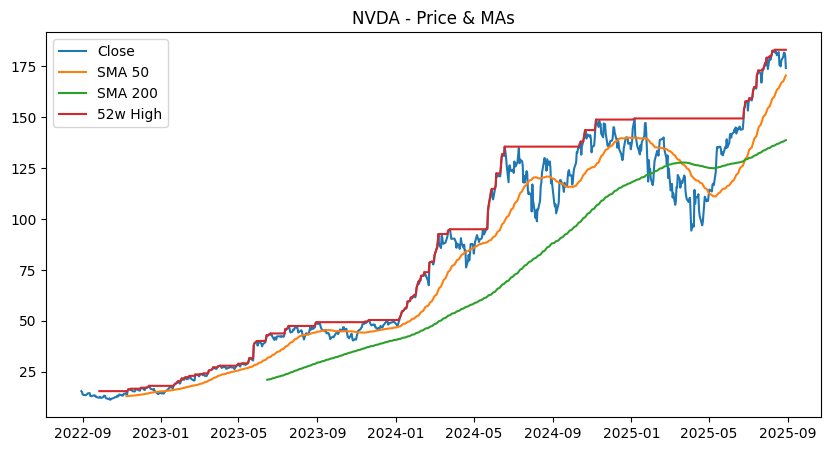

In [ ]:
import matplotlib.pyplot as plt

def plot_stock(ticker: str):
    px = prices.xs(ticker, axis=1, level="Ticker").copy()
    close = px["Close"].dropna()
    vol   = px["Volume"].dropna()
    ma50  = rolling_sma(close, 50)
    ma200 = rolling_sma(close, 200)
    hi52  = close.rolling(PARAMS["lookback_high_days"], min_periods=20).max()

    plt.figure(figsize=(10,5))
    plt.plot(close, label="Close")
    plt.plot(ma50, label="SMA 50")
    plt.plot(ma200, label="SMA 200")
    plt.plot(hi52, label="52w High")
    plt.title(f"{ticker} - Price & MAs")
    plt.legend()
    plt.show()

# 範例
plot_stock("NVDA")


### 測試 yfinance

/tmp/ipython-input-2837230359.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="2y", interval="1wk")["Close"]
[*********************100%***********************]  4 of 4 completed


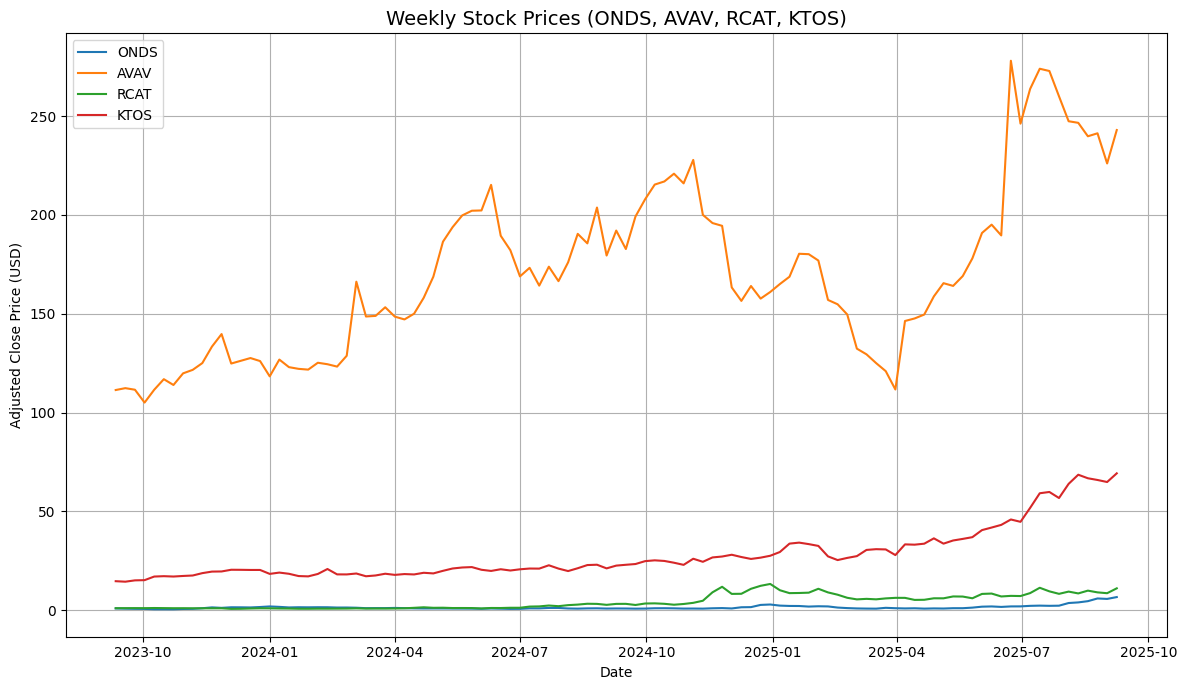

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# 股票代號
tickers = ["ONDS", "AVAV", "RCAT", "KTOS"]

# 抓取近兩年的週線數據
data = yf.download(tickers, period="2y", interval="1wk")["Close"]

plt.figure(figsize=(12,7))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title("Weekly Stock Prices (ONDS, AVAV, RCAT, KTOS)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
